In [1]:
import numpy as np

info=[]
bonds=[]
with open("LastConfig.bfm", "r") as file:
    data = file.readlines()
    for i,line in enumerate(data):
        if (line.startswith("!") or line.startswith("#!")) and "=" in line:
            textstring = line.strip()[1:]
            name = str(textstring[0:textstring.find("=")])
            value = float(textstring[textstring.find("=")+1:])
            index = i
            info.append([name,value,index])

number_of_monomers = info[1][1]
box_x = info[2][1]
box_y = info[3][1]
box_z = info[4][1]
number_of_linear_chains = info[8][1]
number_of_crosslinkers = info[9][1]
chainLength = info[10][1]
mcs = info[-1][1]

bonds = "".join(data[data.index("!bonds\n")+1:info[2][2]]) #the end is when box x starts
bonds = np.fromstring(bonds,sep=" ",dtype=float).reshape(-1, 2)

bondvectors = "".join(data[data.index("!set_of_bondvectors\n")+1:data.index("!attributes\n")-1])

attributes = "".join(data[data.index("!attributes\n")+1:data.index("!reactivity\n")-1])

reactivity = "".join(data[data.index("!reactivity\n")+1:info[8][2]])

conformations = "".join(data[info[13][2]+1:info[13][2]+1+int(info[8][1])]) #the end is adding the number of chains to the first point

crosslinks = "".join(data[info[13][2]+1+int(info[8][1]):])
crosslinks = np.fromstring(crosslinks,sep=" ",dtype=float).reshape(-1, 3)
       
         

# Checking if crosslink positions and first-monomer positions are changed

In [2]:
a = bonds[:,0]<bonds[:,1]
all(a)

True

# Change from monomers ID to chains ID and xlinks ID

In [3]:
aa = bonds[:,0]-1
chainsID = aa//(chainLength)+1

xlink = bonds[:,1]-chainLength*number_of_linear_chains
bondss = np.array([chainsID,xlink]).T

# Sort by chainsID

In [4]:
sorted_bonds = bondss[bondss[:,0].argsort()]

# Check repeated values and calculate conversion rate

In [5]:
values, counts = np.unique(chainsID, return_counts=True)
conversion = 100*len(counts[counts>1])/len(counts)
conversion

98.13344908842862

# Periodic boundary conditions:

In [5]:
print("Crosslink positions with empty spaces: ", crosslinks[crosslinks == None]) #all crosslinks have 3 numbers in positions

xlink_pbc = np.mod(crosslinks, [box_x,box_y,box_z])

print("Crosslinks outside the box: ", "x: ", any(xlink_pbc[:,0]>box_x), "y :", any(xlink_pbc[:,1]>box_y), "z :", any(xlink_pbc[:,2]>box_z))

Crosslink positions with empty spaces:  []
Crosslinks outside the box:  x:  False y : False z : False


# Save the tables

In [213]:
np.savetxt("bonds.txt",sorted_bonds,fmt="%.0f",delimiter="\t",header="chain\tcrosslink")
np.savetxt("crosslinks.txt",xlink_pbc,fmt="%.0f",delimiter="\t",header="x\ty\tz")

In [217]:
%reset -f

# Find the xlinks connected by each chain

In [6]:
chains = sorted_bonds[:,0]

# Find unique chains and indices
unique_chains, inverse = np.unique(chains, return_inverse=True)

chains_xlinks = []

for i, chain in enumerate(unique_chains):
    mask = inverse == i  # all rows for this chain
    associated = sorted_bonds[mask, 1]

    if associated.size < 2:  # skip chains appearing only once
        continue

    chains_xlinks.append([chain] + associated.tolist())

# Pad to max length
max_len = max(len(r) for r in chains_xlinks)
table1_padded = np.array([r + [np.nan]*(max_len-len(r)) for r in chains_xlinks])

# Save to file
np.savetxt(
    "chains_xlinks.txt",
    table1_padded,
    fmt="%.0f",
    delimiter="\t",
    header="\t".join(["chain"] + [f"xlink{i+1}" for i in range(max_len-1)]),
    comments=""
)

# Find the connected xlinks

In [ ]:
chains_xlinks = np.loadtxt("chains_xlinks.txt", skiprows=1, delimiter="\t", dtype=int)
from collections import defaultdict

connections = defaultdict(set)  # xlinkID -> set of connected xlinks

for row in chains_xlinks:
    x1, x2 = row[1], row[2]  # xlinks in this chain
    connections[x1].add(x2)
    connections[x2].add(x1)  # undirected connection
max_len = max(len(v) for v in connections.values())

rows = []
for xlink, conn in connections.items():
    row = [xlink] + list(conn)  # first column is xlinkID
    row += [0]*(max_len - len(conn))  # pad with 0
    rows.append(row)

rows = np.array(rows)
header = "\t".join(["xlinkID"] + [f"xlink_{i+1}" for i in range(max_len)])
np.savetxt("connected_xlinks.txt", rows, fmt="%.0f", delimiter="\t", header=header, comments="")


# Add the positions of each xlink

In [4]:
import numpy as np

crosslinks = np.loadtxt("crosslinks.txt",skiprows=1,delimiter="\t",dtype=float)
box_x = 256
box_y = 256
box_z = 256
threshold = [box_x, box_y, box_z]
xlink_pbc = np.mod(crosslinks, threshold)

connected_xlinks = np.loadtxt("connected_xlinks.txt",skiprows=1,delimiter="\t",dtype=float)
ID_position=[]
connections_positions = []
for i in range(len(connected_xlinks)):
    ID = connected_xlinks[i,0]
    ID_position.append(xlink_pbc[int(ID)-1])
    connections = connected_xlinks[i,1:]
    idx = connections.astype(int) - 1
    idx = idx[idx != -1] #zeros values do not add connections now
    position_connections = xlink_pbc[idx]
    connections_positions.append(position_connections)
    

# Computing distances and center of mass (COM) considering periodic boundary conditions

## BAD

In [15]:
total_list = []
prev_disp = np.inf
total_displacement = 0
ms = 1    
threshold = np.array([box_x,box_y,box_z])

while prev_disp-total_displacement > 1e-6:
    prev_disp = total_displacement
    total_displacement = 0
    indices = np.random.permutation(len(ID_position))
    for i in indices: #runs over xlinks
        #COM_pbc = []
        distance = connections_positions[i]-ID_position[i]
        for j in range(len(distance)): #runs over connections for each xlink
            mask = np.abs(distance[j]) > threshold//2
            for k in range(len(mask)): #runs over coordinates xyz for each connection
                if mask[k] and distance[j][k]>0:
                    virtual_positions = connections_positions[i][j][k]-threshold[k]
                    #distance[j][k] = virtual_positions-ID_position[i][k]
                    distance[j][k] = virtual_positions
                    if distance[j][k] >= threshold[k]//2:
                        print(distance[j][k])
                if mask[k] and distance[j][k]<0:
                    virtual_positions = connections_positions[i][j][k]+threshold[k]
                    #distance[j][k] = virtual_positions-ID_position[i][k]
                    distance[j][k] = virtual_positions
                    if -distance[j][k] >= threshold[k]//2:
                        print(distance[j][k])
                #distances.append(distance)
        
        COM = np.mean(distance,axis=0)
        displacement = np.linalg.norm(COM)
        COM_pbc = np.mod(COM, [box_x,box_y,box_z])
        #print(COM_pbc)
        #print(displacement)
        total_displacement += displacement

        #ID_position[i] += COM
    print(ms, prev_disp-total_displacement)
    ms +=1

1 -2603945.9187273746


## GOOD

In [4]:
import numpy as np

threshold = np.array([256, 256, 256])

# Load crosslink positions
positions = np.loadtxt("crosslinks-positions.txt")

# Load connection table (first column = ID, next columns = connected IDs)
connections = np.loadtxt("connected_xlinks.txt", skiprows=1, delimiter="\t", dtype=int)

# Build a list of position arrays for each xlink
connected_positions = []

for row in connections:
    xlink_id = int(row[0])
    
    # keep only positive IDs (ignore 0, -1, etc.)
    connected_ids = row[1:][row[1:] > 0]
    
    # Get the position of this xlink
    self_pos = positions[xlink_id - 1]  # -1 for 1-based IDs
    
    # Get positions of connected xlinks (skip if no valid ones)
    connected_pos = positions[connected_ids - 1] if connected_ids.size > 0 else np.empty((0, 3))
    
    # Prepend self position
    combined = np.vstack([self_pos, connected_pos])
    
    connected_positions.append(combined)

# Convert to an object array (since subarrays may have different lengths)
connected_positions = np.array(connected_positions, dtype=object)

# Example: print first xlink (self + its connections)

def minimum_image_3d(r1, r2, box_length=256):
    """
    Compute displacement vector using minimum image convention in 3D box [0, L]^3.
    Returns the shortest positive displacement components in [0, L/2].
    """
    delta = r1 - r2
    delta = np.abs(delta)
    delta = np.where(delta > box_length / 2, box_length - delta, delta)
    return delta


# Monte Carlo parameters
max_steps = 1000
tolerance = 1e-15  # convergence criterion

step = 0
max_displacement = np.inf
L = 256

while max_displacement > tolerance and step < max_steps:
    max_displacement = 0.0
    #indices = np.random.permutation(np.arange(len(connected_positions)))
    indices = np.arange(len(connected_positions))
    # Update each point individually
    for i in indices:
        # Ensure current position is inside the box
        connected_positions[i][0] = connected_positions[i][0] % L
        COM = np.mean(connected_positions[i][1:],axis=0)
        # Compute periodic displacement toward COM (minimum image)
        #delta = COM - connected_positions[i][0]
        delta = minimum_image_3d(COM, connected_positions[i][0], box_length=L)
        # Move halfway toward COM
        new_pos = connected_positions[i][0] + 1 * delta
        new_pos = new_pos % L

        # Compute displacement magnitude for convergence check
        displacement = np.linalg.norm(delta / 2)
        if displacement > max_displacement:
            max_displacement = displacement
            print(f"Step {step}, Xlink {i}, Displacement: {displacement:.6f}")
        # Update position
        update_xlink_position_by_id(xlink_id=i, new_position=new_pos, positions=positions, connections=connections, connected_positions=connected_positions)
    displacement=0
    step += 1
    print(f"Monte Carlo smoothing finished in {step} steps. Max displacement: {max_displacement:.6f}")

# 4. Combine IDs with smoothed positions
ids = np.arange(1, len(xlink_position) + 1).reshape(-1, 1)
points_with_ids = np.hstack([ids, xlink_position])

print(f"Monte Carlo smoothing finished in {step} steps. Max displacement: {max_displacement:.6f}")
print(points_with_ids.round(3))

# 5. Clean up
if False:
    del current_positions, lattice_positions, ids, points_with_ids
    del coords_x, coords_y, coords_z, x, y, z, positions, indices, L

Step 0, Xlink 0, Displacement: 90.925966
Step 0, Xlink 6, Displacement: 100.576541
Step 0, Xlink 38, Displacement: 109.054531
Step 0, Xlink 52, Displacement: 116.053328
Step 0, Xlink 105, Displacement: 116.616961
Step 0, Xlink 225, Displacement: 137.238729


KeyboardInterrupt: 

In [94]:
connected_positions[7][:]

array([[  26.,    4.,   23.],
       [ 538., -252., -233.],
       [ 270.,  247.,   15.],
       [  25.,  256.,  269.]])

Connections for xlink 0 (self + neighbors):
 [[  28.  -20.  515.]
 [  22.  -44.   17.]
 [ 261.  -18.  271.]
 [-223. -256.  256.]
 [ 257.  766.    1.]]


In [2]:
def update_xlink_position_by_id(xlink_id, new_position, positions, connections, connected_positions):
    """
    Update all occurrences of a given xlink_id inside connected_positions
    using connection IDs instead of comparing coordinates.

    Args:
        xlink_id (int): The xlink ID to update (1-based indexing).
        new_position (array-like): New [x, y, z] position.
        positions (np.ndarray): Array of shape (N, 3), modified in place.
        connections (np.ndarray): Connection table (IDs, 1-based).
        connected_positions (list[np.ndarray]): List of (k_i, 3) position arrays.
    """
    new_position = np.asarray(new_position, dtype=float)

    # Update the main positions array
    positions[xlink_id - 1] = new_position

    # Loop through each xlink’s connections and update matching positions
    for i, row in enumerate(connections):
        main_id = int(row[0])

        # Build the list of connected IDs (filter valid ones)
        connected_ids = row[1:][row[1:] > 0]

        # Combine main ID + connected IDs (these correspond to connected_positions[i] rows)
        all_ids = np.concatenate(([main_id], connected_ids))

        # Find which rows in connected_positions[i] correspond to our target ID
        mask = (all_ids == xlink_id)

        if np.any(mask):
            connected_positions[i][mask] = new_position

    #print(f"✅ Updated xlink {xlink_id} to new position {new_position} everywhere.")

# Save the final position of the crosslinks

In [37]:
np.savetxt("final_positions.txt",xlink_position,
           fmt="%.3f %.3f %.3f",
           header="ID X Y Z",
           comments='')  # comments='' avoids the default '#' before header

# TOY MODEL: lattice

KeyboardInterrupt: 

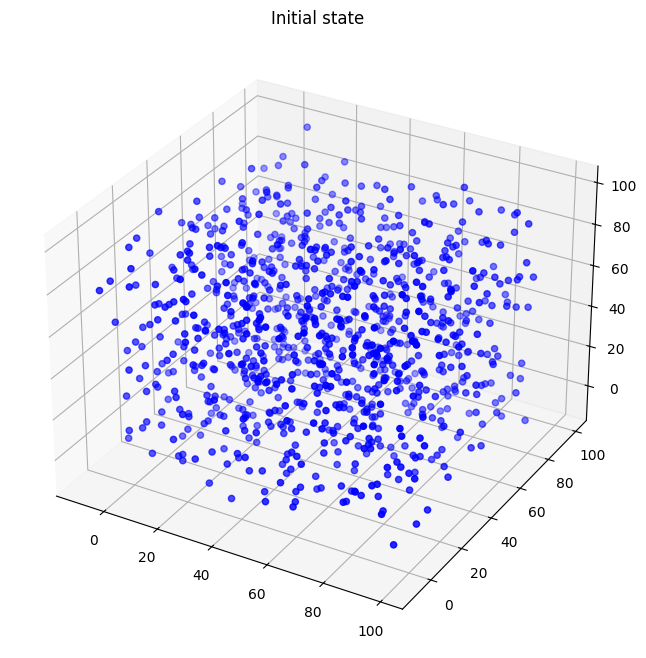

In [8]:
import numpy as np
import matplotlib.pyplot as plt
cube_size = np.array([100, 100, 100])
points_per_axis = 10
total_points = 1000

# Monte Carlo parameters
max_steps = 10000
tolerance = 1e-15 # convergence criterion

# 1. Create cubic lattice
coords_x = np.linspace(0, cube_size[0], points_per_axis, endpoint=False)
coords_y = np.linspace(0, cube_size[1], points_per_axis, endpoint=False)
coords_z = np.linspace(0, cube_size[2], points_per_axis, endpoint=False)
x, y, z = np.meshgrid(coords_x, coords_y, coords_z, indexing='ij')
lattice_positions = np.vstack([x.ravel(), y.ravel(), z.ravel()]).T

# 2. Add initial random noise
current_positions = lattice_positions + np.random.uniform(-10, 10, lattice_positions.shape)

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(current_positions[:,0], current_positions[:,1], current_positions[:,2], color='blue')
plt.title("Initial state")

# 3. Monte Carlo averaging loop using Fisher-Yates for random update order
step = 0
max_displacement = np.inf
L = cube_size

while max_displacement > tolerance and step < max_steps:
    max_displacement = 0.0

    indices = np.random.permutation(np.arange(total_points))

    # Update each point individually
    for i in indices:
        # Ensure current position is inside the box
        current_positions[i] = current_positions[i] % L

        # Compute periodic displacement toward lattice (minimum image)
        delta = lattice_positions[i] - current_positions[i]
        delta = (delta + 0.5 * L) % L - 0.5 * L

        # Move halfway toward lattice
        new_pos = current_positions[i] + 0.5 * delta
        new_pos = new_pos % L

        # Compute displacement magnitude for convergence check
        displacement = np.linalg.norm(delta / 2)
        if displacement > max_displacement:
            max_displacement = displacement

        # Update position
        current_positions[i] = new_pos

    step += 1
    #np.savetxt("testfile-"+str(step)+".txt",indices)
# 4. Combine IDs with smoothed positions
ids = np.arange(1, total_points + 1).reshape(-1, 1)
points_with_ids = np.hstack([ids, current_positions])

print(f"Monte Carlo smoothing finished in {step} steps. Max displacement: {max_displacement:.50f}")
print(points_with_ids.round(1))

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(points_with_ids[:,1], points_with_ids[:,2], points_with_ids[:,3], color='blue')
plt.title("Equilibrium")

# 5. Clean up
#del current_positions, lattice_positions, ids, points_with_ids
#del coords_x, coords_y, coords_z, x, y, z, positions, indices, L

# Plot of the lattice

Text(0.5, 0.92, 'Equilibrium')

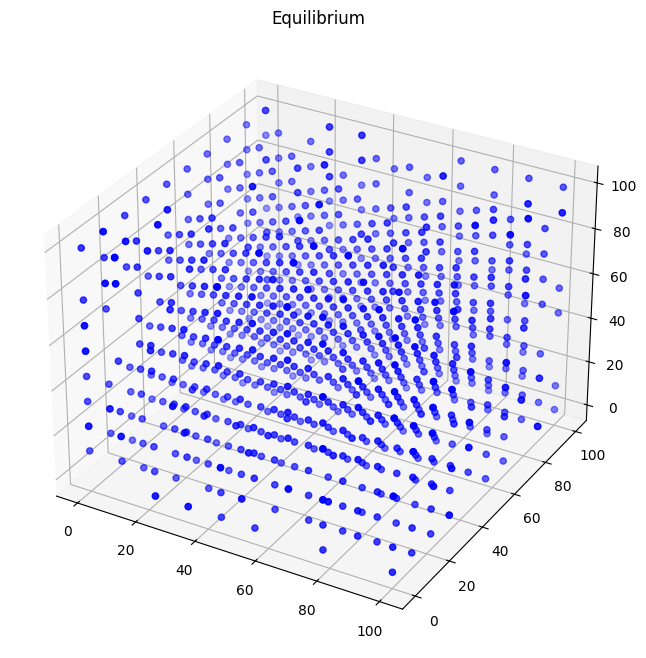

In [68]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(points_with_ids[:,1], points_with_ids[:,2], points_with_ids[:,3], color='blue')
plt.title("Equilibrium")

Text(0.5, 0.92, 'Lattice')

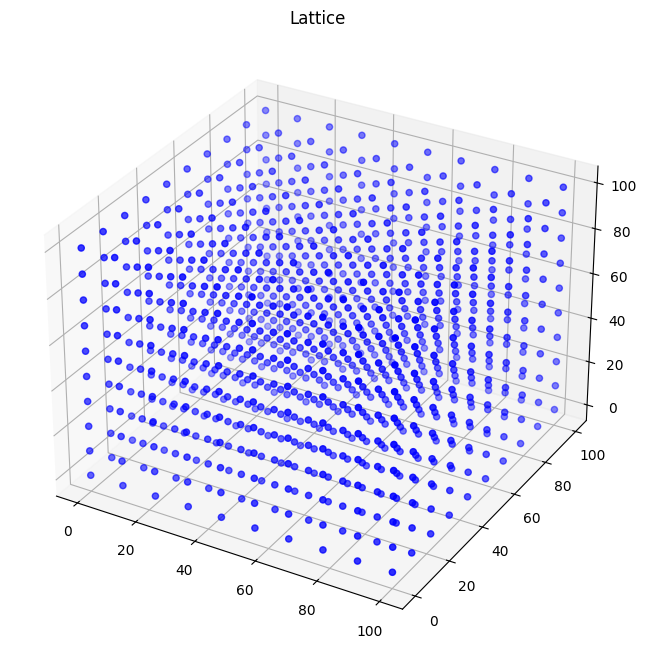

In [70]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(lattice_positions[:,0], lattice_positions[:,1], lattice_positions[:,2], color='blue')
plt.title("Lattice")

In [17]:
import numpy as np
import os
import glob
from collections import Counter

# Folder containing the test files
folder_path = "."
file_pattern = os.path.join(folder_path, "testf*")
files = glob.glob(file_pattern)

if not files:
    raise FileNotFoundError("No files found starting with 'testf'")

# Load and flatten all files
data_list = []
for file in files:
    try:
        data = np.loadtxt(file)
        data_list.append(data.flatten())
        print(f"Loaded {file} with {data.size} elements.")
    except Exception as e:
        print(f"Could not load {file}: {e}")

# Build a global counter of all numbers across files
counter = Counter()
for arr in data_list:
    counter.update(arr)

# Convert to numpy arrays for analysis
unique_numbers = np.array(list(counter.keys()))
counts = np.array(list(counter.values()))

# Each unique number should appear once per file if all contain the same numbers
expected_count = len(files)
all_match = np.all(counts == expected_count)

print("\n=== SUMMARY ===")
print(f"Number of files: {expected_count}")
print(f"Unique numbers found: {len(unique_numbers)}")
print(f"All files contain the same numbers (any order): {all_match}")

if not all_match:
    print("\nNumbers that don't appear in all files:")
    mismatched = unique_numbers[counts != expected_count]
    print(mismatched)


Loaded ./testfile-19.txt with 1000 elements.
Loaded ./testfile-17.txt with 1000 elements.
Loaded ./testfile-10.txt with 1000 elements.
Loaded ./testfile-22.txt with 1000 elements.
Loaded ./testfile-4.txt with 1000 elements.
Loaded ./testfile-3.txt with 1000 elements.
Loaded ./testfile-23.txt with 1000 elements.
Loaded ./testfile-11.txt with 1000 elements.
Loaded ./testfile-16.txt with 1000 elements.
Loaded ./testfile-18.txt with 1000 elements.
Loaded ./testfile-2.txt with 1000 elements.
Loaded ./testfile-5.txt with 1000 elements.
Loaded ./testfile-8.txt with 1000 elements.
Loaded ./testfile-6.txt with 1000 elements.
Loaded ./testfile-1.txt with 1000 elements.
Loaded ./testfile-20.txt with 1000 elements.
Loaded ./testfile-15.txt with 1000 elements.
Loaded ./testfile-12.txt with 1000 elements.
Loaded ./testfile-7.txt with 1000 elements.
Loaded ./testfile-9.txt with 1000 elements.
Loaded ./testfile-13.txt with 1000 elements.
Loaded ./testfile-14.txt with 1000 elements.
Loaded ./testfile-2

In [178]:
cube_size = np.array([100, 100, 100])
points_per_axis = 10
total_points = 100

# Monte Carlo parameters
tolerance = 1e-6  # convergence criterion

# 1. Create cubic lattice
coords_x = np.linspace(0, cube_size[0], points_per_axis)
coords_y = np.linspace(0, cube_size[1], points_per_axis)
coords_z = np.linspace(0, cube_size[2], points_per_axis)
x, y, z = np.meshgrid(coords_x, coords_y, coords_z, indexing='ij')
positions = np.vstack([x.ravel(), y.ravel(), z.ravel()]).T
indices = np.linspace(0, positions.shape[0]-1, total_points, dtype=int)
lattice_positions = positions[indices].copy()  # reference lattice

# 2. Add initial random noise
current_positions = lattice_positions + np.random.uniform(-5, 5, lattice_positions.shape)

# 3. PBC smoothing loop (adapted from your averaging loop)
total_displacement = np.inf
threshold = cube_size
ms = 0

while total_displacement > tolerance:
    max_displacement = 0
    indices = np.random.permutation(total_points)

    for i in indices:
        # Compute periodic displacement toward lattice (minimum image)
        delta = lattice_positions[i] - current_positions[i]
        delta = (delta + 0.5*threshold) % threshold - 0.5*threshold

        # Move halfway toward lattice
        new_pos = (current_positions[i] + delta / 2) % threshold

        # Compute actual movement for convergence check
        delta_move = (new_pos - current_positions[i] + 0.5*threshold) % threshold - 0.5*threshold
        displacement = np.linalg.norm(delta_move)

        if displacement > max_displacement:
            max_displacement = displacement

        # Update position
        current_positions[i] = new_pos

    total_displacement = max_displacement
    ms += 1
    print(ms, total_displacement)

# 4. Save positions with IDs to a readable text file
ids = np.arange(1, total_points+1).reshape(-1, 1)
points_with_ids = np.hstack([ids, current_positions])
np.savetxt("lattice_positions.txt", points_with_ids,
           fmt="%d %.6f %.6f %.6f",
           header="ID X Y Z", comments='')

# 5. Clean up
del current_positions, lattice_positions, ids, points_with_ids
del coords_x, coords_y, coords_z, x, y, z, positions, indices, threshold

1 3.984005262481195
2 1.9920026312405996
3 0.996001315620302
4 0.49800065781014713
5 0.24900032890507534
6 0.1245001644525398
7 0.06225008222626598
8 0.031125041113134688
9 0.015562520556565559
10 0.007781260278280652
11 0.0038906301391421106
12 0.0019453150695731831
13 0.000972657534782679
14 0.00048632876739355507
15 0.00024316438370069012
16 0.00012158219185034506
17 6.079109592517253e-05
18 3.03955479582429e-05
19 1.5197773979464434e-05
20 7.598886989820019e-06
21 3.7994434966948074e-06
22 1.899721748259602e-06
23 9.498608723450028e-07


In [ ]:
cube_size = np.array([100, 100, 100])
points_per_axis = 10
total_points = points_per_axis ** 3  # total lattice points
neighbors_per_point = 4  # four closest neighbors

# Convergence parameters
tolerance = 1e-6
max_steps = 1000

# 1. Create cubic lattice
coords = [np.linspace(0, cube_size[i], points_per_axis) for i in range(3)]
x, y, z = np.meshgrid(*coords, indexing='ij')
lattice_positions = np.vstack([x.ravel(), y.ravel(), z.ravel()]).T

# 2. Add random initial noise
current_positions = lattice_positions + np.random.uniform(-5, 5, lattice_positions.shape)

# 3. Build neighbor list deterministically based on grid indices
def index_to_ijk(idx):
    i = idx // (points_per_axis**2)
    j = (idx // points_per_axis) % points_per_axis
    k = idx % points_per_axis
    return i, j, k

def ijk_to_index(i, j, k):
    return (i % points_per_axis) * points_per_axis**2 + (j % points_per_axis) * points_per_axis + (k % points_per_axis)

neighbor_indices = []
for idx in range(total_points):
    i, j, k = index_to_ijk(idx)
    # Pick 4 neighbors (±x, ±y, ±z, wrap around for PBC)
    neighbors = [
        ijk_to_index(i+1, j, k),
        ijk_to_index(i-1, j, k),
        ijk_to_index(i, j+1, k),
        ijk_to_index(i, j-1, k)
    ]
    neighbor_indices.append(neighbors)

neighbor_indices = np.array(neighbor_indices)

# 4. Iterative relaxation toward COM of neighbors
step = 0
max_displacement = np.inf

while max_displacement > tolerance and step < max_steps:
    max_displacement = 0.0
    indices = np.random.permutation(total_points)  # random update order

    for i in indices:
        neighbors = neighbor_indices[i]
        # Compute displacement vectors with PBC
        delta = current_positions[neighbors] - current_positions[i]
        delta = (delta + 0.5 * cube_size) % cube_size - 0.5 * cube_size

        # Center of mass relative to current position
        COM = np.mean(delta, axis=0)

        # Update position
        new_pos = (current_positions[i] + COM) % cube_size

        # Track displacement
        displacement = np.linalg.norm(COM)
        if displacement > max_displacement:
            max_displacement = displacement

        current_positions[i] = new_pos

    step += 1
    print(f"Step {step}, max displacement: {max_displacement:.6f}")
print()
# 5. Save final positions with IDs
ids = np.arange(1, total_points+1).reshape(-1, 1)
points_with_ids = np.hstack([ids, current_positions])


print("Relaxation complete.")

Step 1, max displacement: 11.714247
Step 2, max displacement: 4.558028
Step 3, max displacement: 1.928220
Step 4, max displacement: 1.304617
Step 5, max displacement: 0.953466
Step 6, max displacement: 0.907382
Step 7, max displacement: 0.618018
Step 8, max displacement: 0.502010
Step 9, max displacement: 0.452719
Step 10, max displacement: 0.353390
Step 11, max displacement: 0.362311
Step 12, max displacement: 0.266702
Step 13, max displacement: 0.242484
Step 14, max displacement: 0.218696
Step 15, max displacement: 0.151880
Step 16, max displacement: 0.142612
Step 17, max displacement: 0.115253
Step 18, max displacement: 0.101140
Step 19, max displacement: 0.087599
Step 20, max displacement: 0.074888
Step 21, max displacement: 0.060492
Step 22, max displacement: 0.053265
Step 23, max displacement: 0.044425
Step 24, max displacement: 0.039754
Step 25, max displacement: 0.032715
Step 26, max displacement: 0.027051
Step 27, max displacement: 0.022940
Step 28, max displacement: 0.021674
